# **Ventas de Supermercado**

## Importación de la Base

In [17]:
import pandas as pd

df = pd.read_csv("../data/supermarket_sales.csv")
df.head()


,order_id,order_date,city,product,category,quantity,unit_price,total
0,1001,2023-01-05,Bogota,Arroz 1kg,Abarrotes,3,4500,13500
1,1002,2023-01-05,Bogota,Leche 1L,Lacteos,6,3200,19200
2,1003,2023-01-06,Medellin,Huevos 12u,Abarrotes,2,9800,19600
3,1004,2023-01-06,Bogota,Pan tajado,Panaderia,4,4200,16800
4,1005,2023-01-07,Cali,Gaseosa 1.5L,Bebidas,5,5500,27500


## Tipo de Datos

In [18]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["quantity"] = df["quantity"].astype(int)
df["unit_price"] = df["unit_price"].astype(float)
df["total"] = df["total"].astype(float)

df.dtypes


order_id               int64
order_date    datetime64[ns]
city                  object
product               object
category              object
quantity               int64
unit_price           float64
total                float64
dtype: object

## Normalizar Texto

In [19]:
df["city"] = df["city"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()

df[["city", "category"]].drop_duplicates()


,city,category
0,Bogota,Abarrotes
1,Bogota,Lacteos
2,Medellin,Abarrotes
3,Bogota,Panaderia
4,Cali,Bebidas
6,Medellin,Lacteos
7,Cali,Abarrotes
8,Bogota,Limpeza
9,Bogota,Hogar


## Verificar duplicados y nulos

In [20]:
df.isna().sum(), df.duplicated().sum()


(order_id      0
 order_date    0
 city          0
 product       0
 category      0
 quantity      0
 unit_price    0
 total         0
 dtype: int64,
 np.int64(0))

## Ventas por ciudad

In [22]:
sales_by_city = (
    df.groupby("city", as_index=False)["total"]
      .sum()
      .sort_values("total", ascending=False)
)

sales_by_city


,city,total
0,Bogota,125000.0
1,Cali,45900.0
2,Medellin,34000.0


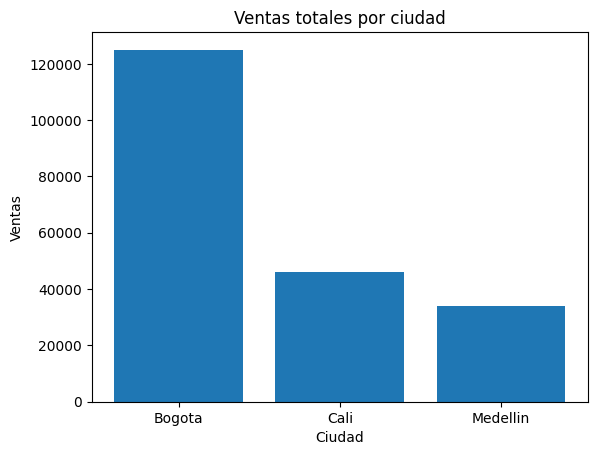

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(sales_by_city["city"], sales_by_city["total"])
plt.title("Ventas totales por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ventas")
plt.show()


## Ventas por Categoria

In [23]:
sales_by_category = (
    df.groupby("category", as_index=False)["total"]
      .sum()
      .sort_values("total", ascending=False)
)

sales_by_category


,category,total
0,Abarrotes,76500.0
3,Lacteos,33600.0
4,Limpeza,31600.0
1,Bebidas,27500.0
2,Hogar,18900.0
5,Panaderia,16800.0


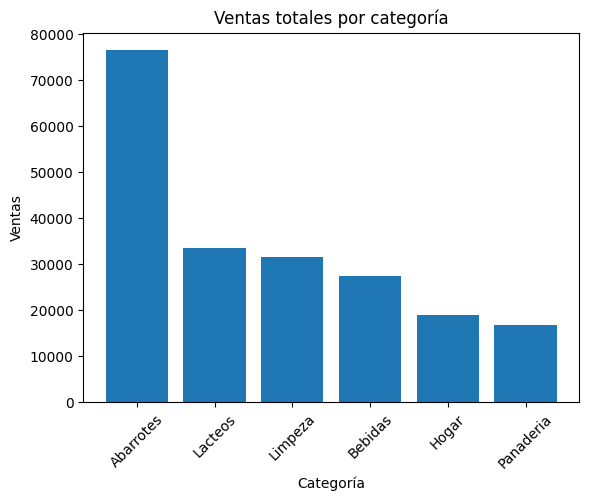

In [15]:
plt.figure()
plt.bar(sales_by_category["category"], sales_by_category["total"])
plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.show()


## Ventas totales

In [21]:
total_sales = df["total"].sum()
print(f"Ventas totales: ${total_sales:,.0f}")



Ventas totales: $204,900


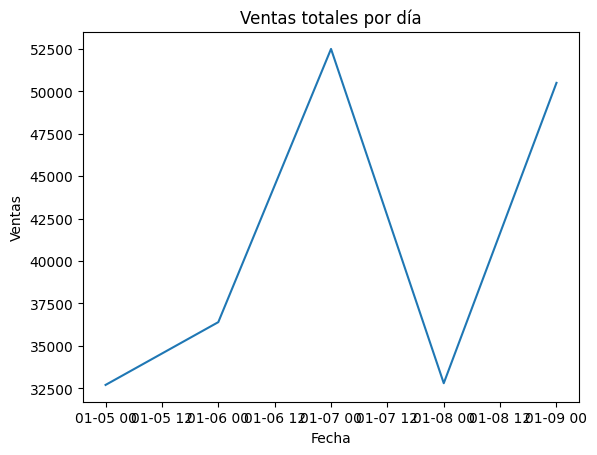

In [16]:
sales_by_date = (
    df.groupby("order_date", as_index=False)["total"].sum()
)

plt.figure()
plt.plot(sales_by_date["order_date"], sales_by_date["total"])
plt.title("Ventas totales por día")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()


## Conclusiones

- La ciudad con mayor volumen de ventas es **Bogotá**, lo que indica una mayor demanda y concentración de clientes.
- La categoría **Abarrotes** concentra la mayor parte de los ingresos, seguida por **Lácteos**.
- Se observan variaciones en las ventas a lo largo del tiempo, permitiendo identificar días de mayor actividad.
- El análisis permite enfocar estrategias comerciales en ciudades y categorías con mejor desempeño.
